# California Model Evaluation — Gap Analysis

Addresses three gaps identified in `model_evaluation.ipynb`:

| # | Gap | Root question |
|---|-----|--------------|
| 1 | **t+24h exceedance recall ≈ 0.00** at most sites | Why does the regression model forecast ozone levels correctly on average but almost never pre-flag exceedance events 24 h ahead? |
| 2 | **LPO010 / DEV412 have no training data** | How much does SITE_ID_enc extrapolation degrade predictions for sites never seen in training? |
| 3 | **LAV410 R²=0.40 at t+24h** | Is the poor skill driven by different ozone chemistry, fire-year effects, or a feature-set mismatch specific to the Cascades regime? |

**Prerequisites:** `model_evaluation.ipynb` (Step 6) must have been run. This notebook reads
the `step6_evaluation.pkl` bundle and the Step 4 model artefacts directly.

## Section 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import os, gc, pickle, warnings
warnings.filterwarnings('ignore')

import dask.dataframe as dd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve, roc_auc_score, average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})

print(f'pandas    : {pd.__version__}')
print(f'lightgbm  : {lgb.__version__}')

pandas    : 2.2.2
lightgbm  : 4.6.0


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = r'C:\MATH699P\Data'
CA_DIR     = os.path.join(DATA_DIR, 'processed_data', 'california')
FE_DIR     = os.path.join(CA_DIR,   'features_parquet')
INPUT_PATH = os.path.join(FE_DIR,   'features_engineered')
META_PATH  = os.path.join(FE_DIR,   'ca_feature_metadata.pkl')
STEP4_DIR  = os.path.join(FE_DIR,   'model_prep')
EVAL_DIR   = os.path.join(FE_DIR,   'model_evaluation')
OUTPUT_DIR = os.path.join(FE_DIR,   'eval_gap_analysis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONFIG = {
    'train_end'      : '2018-12-31',
    'val_start'      : '2019-01-01',
    'val_end'        : '2020-12-31',
    'test_start'     : '2021-01-01',
    'horizons'       : [1, 8, 24],
    'naaqs_threshold': 70.0,
    'fire_months'    : [6, 7, 8, 9, 10],
    'site_clusters'  : {
        'Coastal'         : ['CAN407'],
        'Mountain-Sierra' : ['SEK402','SEK430','YOS404','YOS204'],
        'Desert-Inland'   : ['JOT403','SND152'],
        'Cascades-North'  : ['LAV410','TRI193'],
        'Central-Coast'   : ['PIN414'],
        'Other'           : ['CON186','DEV412','LPO010','ABF404','SAN405'],
    },
    # Sites known to have zero training rows
    'no_train_sites' : ['DEV412', 'LPO010'],
    # Reference site for LAV410 comparison
    'lav_peers'      : ['YOS404', 'SEK430', 'JOT403'],
}

SITE_CLUSTER = {s: cl for cl, sites in CONFIG['site_clusters'].items() for s in sites}
CLUSTER_COLORS = {
    'Coastal':'#1E88E5','Mountain-Sierra':'#43A047','Desert-Inland':'#E53935',
    'Cascades-North':'#8E24AA','Central-Coast':'#FB8C00','Other':'#757575',
}

# ── Load artefacts ────────────────────────────────────────────────────────────
with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)
FEATURE_COLS = meta['feature_cols']
ca_sites     = meta['ca_sites']

with open(os.path.join(STEP4_DIR, 'train_medians.pkl'), 'rb') as f:
    inf_art = pickle.load(f)
FEATURE_COLS_EXT = inf_art['feature_cols']
le_site          = inf_art['site_encoder']
_med_raw         = inf_art['medians']
MEDIANS = _med_raw if isinstance(_med_raw, dict) else {H: _med_raw for H in CONFIG['horizons']}
def get_medians(H):
    return MEDIANS.get(H, next(iter(MEDIANS.values())))

global_reg = {}
for H in CONFIG['horizons']:
    p = os.path.join(STEP4_DIR, f'lgb_reg_t{H}.txt')
    if os.path.exists(p):
        global_reg[H] = lgb.Booster(model_file=p)
        print(f'  Loaded global reg t+{H}h')

clf_path   = os.path.join(STEP4_DIR, 'lgb_clf_naaqs_t8.txt')
global_clf = lgb.Booster(model_file=clf_path) if os.path.exists(clf_path) else None
print(f'  NAAQS classifier: {"loaded" if global_clf else "NOT FOUND"}')
print(f'  CA sites: {sorted(ca_sites)}')

  Loaded global reg t+1h
  Loaded global reg t+8h
  Loaded global reg t+24h
  NAAQS classifier: loaded
  CA sites: ['CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'SND152', 'YOS204', 'YOS404']


In [3]:
# ── Load data and rebuild test predictions ────────────────────────────────────
print('Loading Parquet...')
import glob as _glob, os as _os
_part_dirs = sorted(_glob.glob(_os.path.join(INPUT_PATH, 'SITE_ID=*')))
if _part_dirs:
    _parts = []
    for _pdir in _part_dirs:
        _sid = _os.path.basename(_pdir).split('=', 1)[1]
        try:
            _chunk = pd.read_parquet(_pdir, engine='pyarrow')
        except Exception:
            _chunk = pd.read_parquet(_pdir)
        _chunk['SITE_ID'] = _sid
        _parts.append(_chunk)
        print(f'  {_sid}: {len(_chunk):,} rows')
    df = pd.concat(_parts, ignore_index=True)
    del _parts; gc.collect()
else:
    df = pd.read_parquet(INPUT_PATH, engine='pyarrow')
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.sort_values(['SITE_ID','DATE_TIME']).reset_index(drop=True)
_n_before = len(df)
df = df.drop_duplicates(subset=['SITE_ID','DATE_TIME'], keep='last')
if (_nd := _n_before - len(df)):
    print(f'  ⚠  Dropped {_nd:,} duplicate rows')
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

for s in df['SITE_ID'].unique():
    if s not in SITE_CLUSTER:
        SITE_CLUSTER[s] = 'Other'

train_end_ts = pd.Timestamp(CONFIG['train_end'])
val_end_ts   = pd.Timestamp(CONFIG['val_end'])
site_dfs = []
for sid, grp in df.groupby('SITE_ID'):
    grp = grp.sort_values('DATE_TIME').copy()
    for H in CONFIG['horizons']:
        grp[f'OZONE_t{H}'] = grp['OZONE'].shift(-H).astype('float32')
    grp['NAAQS_exceed_t8'] = (grp['OZONE_t8'] > CONFIG['naaqs_threshold']).astype('float32')
    site_dfs.append(grp)
# sort_values omitted: groupby guarantees SITE_ID order;
# each grp already sorted by DATE_TIME inside the loop.
df = pd.concat(site_dfs, ignore_index=True)

def add_site_enc(X, meta_df):
    X = X.copy()
    X['SITE_ID_enc'] = le_site.transform(meta_df['SITE_ID'].values).astype('int8')
    return X

test_mask = df['DATE_TIME'] >= pd.Timestamp(CONFIG['test_start'])

test_preds = {}
for H in CONFIG['horizons']:
    # Column-prune before copy — avoids 80-col vstack OOM on .copy().
    # Keep features + the handful of columns used to annotate sub.
    _keep = list(dict.fromkeys(
        ['SITE_ID','DATE_TIME','OZONE','month','hour',
         f'OZONE_t{H}','NAAQS_exceed_t8'] + FEATURE_COLS
    ))
    _keep = [c for c in _keep if c in df.columns]
    sub = df.loc[test_mask & df[f'OZONE_t{H}'].notna(), _keep].copy()
    X   = add_site_enc(sub[FEATURE_COLS], sub).fillna(get_medians(H))
    sub['y_hat']         = global_reg[H].predict(X).astype('float32')
    sub['resid']         = sub['y_hat'] - sub[f'OZONE_t{H}']
    sub['is_fire_season']= sub['month'].isin(CONFIG['fire_months']).astype(int)
    sub['cluster']       = sub['SITE_ID'].map(SITE_CLUSTER).fillna('Other')
    sub['exceed_actual'] = (sub[f'OZONE_t{H}'] >= CONFIG['naaqs_threshold']).astype(int)
    sub['in_training']   = (~sub['SITE_ID'].isin(CONFIG['no_train_sites'])).astype(int)
    test_preds[H] = sub
    print(f'  t+{H}h: {len(sub):,} rows, {sub["SITE_ID"].nunique()} sites')

if global_clf is not None:
    X8 = add_site_enc(test_preds[8][FEATURE_COLS], test_preds[8]).fillna(get_medians(8))
    test_preds[8]['clf_proba'] = global_clf.predict(X8).astype('float32')

# Also build val predictions for calibration work
val_mask = (df['DATE_TIME'] >= pd.Timestamp(CONFIG['val_start'])) & \
           (df['DATE_TIME'] <= pd.Timestamp(CONFIG['val_end']))
_keep24 = list(dict.fromkeys(
    ['SITE_ID','DATE_TIME','OZONE','month','hour','OZONE_t24','NAAQS_exceed_t8']
    + FEATURE_COLS
))
_keep24 = [c for c in _keep24 if c in df.columns]
val_sub24 = df.loc[val_mask & df['OZONE_t24'].notna(), _keep24].copy()
X_val24 = add_site_enc(val_sub24[FEATURE_COLS], val_sub24).fillna(get_medians(24))
val_sub24['y_hat'] = global_reg[24].predict(X_val24).astype('float32')
val_sub24['exceed_actual'] = (val_sub24['OZONE_t24'] >= CONFIG['naaqs_threshold']).astype(int)
print(f'  Val t+24h: {len(val_sub24):,} rows for threshold tuning')

Loading Parquet...
  CAN407: 246,689 rows
  CON186: 62,570 rows
  DEV412: 153,887 rows
  JOT403: 244,399 rows
  LAV410: 242,746 rows
  LPO010: 12,496 rows
  PIN414: 250,345 rows
  SEK402: 54,390 rows
  SEK430: 165,301 rows
  SND152: 274,143 rows
  YOS204: 8,631 rows
  YOS404: 245,008 rows
  t+1h: 298,126 rows, 9 sites
  t+8h: 298,063 rows, 9 sites
  t+24h: 297,919 rows, 9 sites
  Val t+24h: 132,543 rows for threshold tuning


---
## Gap 1 — t+24h Exceedance Recall ≈ 0.00

The regression model achieves good average RMSE at t+24h but almost never flags
exceedance events (≥70 ppb) 24 hours ahead at most sites. This section diagnoses:

1. **Feature decay** — which predictive features are available at t+1 vs t+24 (lag freshness)
2. **Prediction distribution** — the model systematically under-predicts the right tail at t+24h
3. **Optimal threshold search** — what t+24h regression threshold maximises F1 on val set
4. **Calibrated day-ahead warning** — Platt-scaling the regression output as a pseudo-probability
5. **Temporal pattern** — which times of day / months the misses cluster in

In [4]:
# ── 1a. Feature importance decay across horizons ──────────────────────────────
#
# The model relies heavily on autoregressive features (OZONE_lag_1, OZONE_rmean_3)
# that are 24 hours stale at the t+24 horizon. Show how the importance of these
# features shifts vs features that remain fresh (calendar, met, site static).

LAG_FEATURES = [f for f in FEATURE_COLS if any(
    k in f for k in ['lag','rmean','OZONE_t','diff','trend'])]
STATIC_FEATURES = [f for f in FEATURE_COLS if any(
    k in f for k in ['hour_sin','hour_cos','month_sin','month_cos',
                     'elevation','coast_dist','lat','lon','annual'])]
OTHER_FEATURES = [f for f in FEATURE_COLS
                  if f not in LAG_FEATURES and f not in STATIC_FEATURES]

print('Feature group membership:')
print(f'  Autoregressive (lag/rmean): {len(LAG_FEATURES)}')
print(f'  Static/calendar            : {len(STATIC_FEATURES)}')
print(f'  Other (chem, met, PM)      : {len(OTHER_FEATURES)}')
print()

imp_by_horizon = {}
for H in CONFIG['horizons']:
    if H not in global_reg:
        continue
    imp = global_reg[H].feature_importance(importance_type='gain')
    feat_names = global_reg[H].feature_name()
    imp_series = pd.Series(imp, index=feat_names)
    imp_series = imp_series / imp_series.sum()   # normalise to fractions
    imp_by_horizon[H] = imp_series

    lag_frac    = imp_series[[f for f in LAG_FEATURES    if f in imp_series]].sum()
    static_frac = imp_series[[f for f in STATIC_FEATURES if f in imp_series]].sum()
    other_frac  = imp_series[[f for f in OTHER_FEATURES  if f in imp_series]].sum()
    top5 = imp_series.nlargest(5)
    print(f't+{H}h importance fractions:')
    print(f'  Autoregressive: {lag_frac:.1%}  |  Static/calendar: {static_frac:.1%}  |  Other: {other_frac:.1%}')
    print(f'  Top-5: {top5.index.tolist()}')
    print()

Feature group membership:
  Autoregressive (lag/rmean): 17
  Static/calendar            : 5
  Other (chem, met, PM)      : 79

t+1h importance fractions:
  Autoregressive: 51.6%  |  Static/calendar: 2.3%  |  Other: 45.9%
  Top-5: ['OZONE_rmean_3', 'OZONE_rmax_3', 'OZONE_rmin_3', 'OZONE_diff_1', 'OZONE_lag_1']

t+8h importance fractions:
  Autoregressive: 56.4%  |  Static/calendar: 7.8%  |  Other: 35.4%
  Top-5: ['OZONE_rmean_24', 'OZONE_lag_12', 'OZONE_rmean_168', 'hour_sin', 'hour']

t+24h importance fractions:
  Autoregressive: 51.7%  |  Static/calendar: 4.9%  |  Other: 43.3%
  Top-5: ['OZONE_rmean_3', 'OZONE_rmax_3', 'OZONE_rmean_168', 'hour_cos', 'OZONE_lag_1']



In [5]:
# ── 1b. Prediction distribution: exceedance vs non-exceedance hours ───────────
#
# If the model under-predicts the tail at t+24h, the distribution of y_hat for
# exceedance hours will overlap heavily with non-exceedance predictions.

sub24 = test_preds[24].copy()
exceed_mask = sub24['exceed_actual'] == 1

print('t+24h prediction statistics:')
print(f'  Total test rows        : {len(sub24):,}')
print(f'  True exceedance rows   : {exceed_mask.sum():,} ({exceed_mask.mean():.1%})')
print()
print(f'  y_hat for EXCEEDANCE hours  : mean={sub24.loc[exceed_mask,"y_hat"].mean():.1f}  '
      f'median={sub24.loc[exceed_mask,"y_hat"].median():.1f}  '
      f'p90={sub24.loc[exceed_mask,"y_hat"].quantile(0.9):.1f} ppb')
print(f'  y_hat for NON-EXCEED hours  : mean={sub24.loc[~exceed_mask,"y_hat"].mean():.1f}  '
      f'median={sub24.loc[~exceed_mask,"y_hat"].median():.1f}  '
      f'p90={sub24.loc[~exceed_mask,"y_hat"].quantile(0.9):.1f} ppb')
print()

# Overlap coefficient (how much of the exceedance prediction dist falls below 70 ppb)
frac_below_70 = (sub24.loc[exceed_mask, 'y_hat'] < 70).mean()
print(f'  Fraction of TRUE exceedance hours where y_hat < 70 ppb: {frac_below_70:.1%}')
print(f'  → This is the structural miss rate regardless of threshold choice')
print()

# Per-site breakdown
print('Per-site: fraction of true exceedances with y_hat < 70 ppb (t+24h):')
for sid in sorted(sub24['SITE_ID'].unique()):
    g = sub24[sub24['SITE_ID'] == sid]
    exc = g['exceed_actual'] == 1
    if exc.sum() < 5:
        continue
    under = (g.loc[exc, 'y_hat'] < 70).mean()
    mean_yhat = g.loc[exc, 'y_hat'].mean()
    print(f'  {sid:<8}  n_exc={exc.sum():>5}  mean_y_hat={mean_yhat:>6.1f}  '
          f'pct_below_70={under:.1%}  {"← key problem" if under > 0.5 else ""}')

t+24h prediction statistics:
  Total test rows        : 297,919
  True exceedance rows   : 5,520 (1.9%)

  y_hat for EXCEEDANCE hours  : mean=66.6  median=66.1  p90=79.1 ppb
  y_hat for NON-EXCEED hours  : mean=41.2  median=41.8  p90=54.4 ppb

  Fraction of TRUE exceedance hours where y_hat < 70 ppb: 64.9%
  → This is the structural miss rate regardless of threshold choice

Per-site: fraction of true exceedances with y_hat < 70 ppb (t+24h):
  DEV412    n_exc=  290  mean_y_hat=  59.6  pct_below_70=100.0%  ← key problem
  JOT403    n_exc= 1706  mean_y_hat=  63.0  pct_below_70=86.9%  ← key problem
  LPO010    n_exc=  299  mean_y_hat=  57.0  pct_below_70=100.0%  ← key problem
  PIN414    n_exc=   78  mean_y_hat=  53.9  pct_below_70=100.0%  ← key problem
  SEK430    n_exc= 2731  mean_y_hat=  71.8  pct_below_70=38.5%  
  SND152    n_exc=   29  mean_y_hat=  53.6  pct_below_70=100.0%  ← key problem
  YOS404    n_exc=  387  mean_y_hat=  61.4  pct_below_70=90.7%  ← key problem


In [6]:
# ── 1c. Optimal decision threshold on val set ──────────────────────────────────
#
# Even if the model under-predicts the tail, lowering the decision threshold
# from 70 ppb to some value T* may improve recall at acceptable precision.
# Tune T* on the validation set; report expected test-set performance.

val_exceed = val_sub24['exceed_actual'].values
val_yhat24 = val_sub24['y_hat'].values

# Grid search
thresholds = np.arange(40, 75, 1.0)
results = []
for thr in thresholds:
    flagged  = (val_yhat24 >= thr).astype(int)
    tp = int(((flagged == 1) & (val_exceed == 1)).sum())
    fp = int(((flagged == 1) & (val_exceed == 0)).sum())
    fn = int(((flagged == 0) & (val_exceed == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
    far       = fp / max(1, flagged.sum())   # false alarm rate
    results.append({'thr': thr, 'precision': precision, 'recall': recall,
                    'f1': f1, 'far': far, 'tp': tp, 'fp': fp, 'fn': fn})

thr_df = pd.DataFrame(results)
best_f1_row  = thr_df.loc[thr_df['f1'].idxmax()]
best_rec_row = thr_df.loc[(thr_df['recall'] >= 0.50) & (thr_df['far'] <= 0.20),
                           'f1'].idxmax() if ((thr_df['recall'] >= 0.50) & (thr_df['far'] <= 0.20)).any() else None

print('Val-set threshold tuning for t+24h exceedance detection:')
print(f'  Baseline (70 ppb):  Precision={thr_df[thr_df.thr==70]["precision"].values[0]:.3f}  '
      f'Recall={thr_df[thr_df.thr==70]["recall"].values[0]:.3f}  '
      f'F1={thr_df[thr_df.thr==70]["f1"].values[0]:.3f}')
print(f'  Best F1 threshold ({best_f1_row.thr:.0f} ppb):  '
      f'Precision={best_f1_row.precision:.3f}  Recall={best_f1_row.recall:.3f}  '
      f'F1={best_f1_row.f1:.3f}  FAR={best_f1_row.far:.3f}')
if best_rec_row is not None:
    row = thr_df.loc[best_rec_row]
    print(f'  Recall≥0.5 FAR≤0.20 ({row.thr:.0f} ppb):  '
          f'Precision={row.precision:.3f}  Recall={row.recall:.3f}  '
          f'F1={row.f1:.3f}  FAR={row.far:.3f}')

# Now apply best threshold to test set
OPT_THR = float(best_f1_row.thr)
test_exceed  = sub24['exceed_actual'].values
test_flagged = (sub24['y_hat'].values >= OPT_THR).astype(int)
tp_t = int(((test_flagged==1)&(test_exceed==1)).sum())
fp_t = int(((test_flagged==1)&(test_exceed==0)).sum())
fn_t = int(((test_flagged==0)&(test_exceed==1)).sum())
p_t  = tp_t / (tp_t+fp_t) if (tp_t+fp_t)>0 else 0
r_t  = tp_t / (tp_t+fn_t) if (tp_t+fn_t)>0 else 0
f1_t = 2*p_t*r_t/(p_t+r_t) if (p_t+r_t)>0 else 0
print(f'\n  Test-set at optimal {OPT_THR:.0f} ppb threshold:')
print(f'    Precision={p_t:.3f}  Recall={r_t:.3f}  F1={f1_t:.3f}')
print(f'    TP={tp_t}  FP={fp_t}  FN={fn_t}')

# Per-site test recall at optimal threshold
print(f'\n  Per-site recall at {OPT_THR:.0f} ppb (test set):')
for sid in sorted(sub24['SITE_ID'].unique()):
    g   = sub24[sub24['SITE_ID'] == sid]
    exc = g['exceed_actual'].values
    if exc.sum() < 5:
        continue
    rec = (g['y_hat'].values[exc==1] >= OPT_THR).mean()
    rec70 = (g['y_hat'].values[exc==1] >= 70).mean()
    print(f'    {sid:<8}  @70ppb={rec70:.3f}  @{OPT_THR:.0f}ppb={rec:.3f}  '
          f'Δrecall={rec-rec70:+.3f}')

Val-set threshold tuning for t+24h exceedance detection:
  Baseline (70 ppb):  Precision=0.696  Recall=0.392  F1=0.502
  Best F1 threshold (65 ppb):  Precision=0.525  Recall=0.573  F1=0.548  FAR=0.475

  Test-set at optimal 65 ppb threshold:
    Precision=0.509  Recall=0.546  F1=0.527
    TP=3012  FP=2905  FN=2508

  Per-site recall at 65 ppb (test set):
    DEV412    @70ppb=0.000  @65ppb=0.110  Δrecall=+0.110
    JOT403    @70ppb=0.131  @65ppb=0.373  Δrecall=+0.243
    LPO010    @70ppb=0.000  @65ppb=0.064  Δrecall=+0.064
    PIN414    @70ppb=0.000  @65ppb=0.013  Δrecall=+0.013
    SEK430    @70ppb=0.615  @65ppb=0.811  Δrecall=+0.196
    SND152    @70ppb=0.000  @65ppb=0.000  Δrecall=+0.000
    YOS404    @70ppb=0.093  @65ppb=0.279  Δrecall=+0.186


In [7]:
# ── 1d. Platt-scaled pseudo-probability for t+24h warning ─────────────────────
#
# Calibrate the regression output as a classifier score using logistic regression
# on the val set (Platt scaling). This gives a probability P(exceed | y_hat_t24)
# that can be thresholded at any operating point.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Platt scaling: fit logistic on val y_hat → exceed label
X_platt = val_yhat24.reshape(-1, 1)
y_platt = val_exceed

scaler = StandardScaler()
X_platt_s = scaler.fit_transform(X_platt)
platt = LogisticRegression(C=1.0, max_iter=500)
platt.fit(X_platt_s, y_platt)

# Apply to test
X_test24 = scaler.transform(sub24['y_hat'].values.reshape(-1, 1))
sub24['platt_proba'] = platt.predict_proba(X_test24)[:, 1]

# Evaluate calibrated probabilities
brier = brier_score_loss(test_exceed, sub24['platt_proba'].values)
auc   = roc_auc_score(test_exceed, sub24['platt_proba'].values)
ap    = average_precision_score(test_exceed, sub24['platt_proba'].values)

print('Platt-scaled t+24h pseudo-classifier (val-fitted):')
print(f'  AUC-ROC          : {auc:.4f}')
print(f'  Average Precision: {ap:.4f}')
print(f'  Brier Score      : {brier:.4f}  (0=perfect, 0.25=no-skill)')

# Compare to t+8h NAAQS classifier
if 'clf_proba' in test_preds[8].columns:
    sub8 = test_preds[8]
    exc8 = sub8['exceed_actual'].values
    auc8 = roc_auc_score(exc8, sub8['clf_proba'].values)
    print(f'\n  For comparison — t+8h dedicated NAAQS classifier AUC: {auc8:.4f}')
    print(f'  t+24h Platt-scaled AUC: {auc:.4f}')
    print(f'  AUC gap (8h → 24h): {auc8-auc:+.4f}')

# Precision-recall at several probability thresholds
print('\n  Precision/Recall at probability thresholds (test, Platt-scaled):')
print(f'  {"P(≥)".rjust(8)}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"N flagged":>10}')
print('  ' + '-' * 52)
for pthr in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    flag = (sub24['platt_proba'].values >= pthr).astype(int)
    tp = int(((flag==1)&(test_exceed==1)).sum())
    fp = int(((flag==1)&(test_exceed==0)).sum())
    fn = int(((flag==0)&(test_exceed==1)).sum())
    p  = tp/(tp+fp) if (tp+fp)>0 else 0
    r  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0
    print(f'  {pthr:>8.2f}  {p:>10.3f}  {r:>8.3f}  {f1:>8.3f}  {flag.sum():>10,}')

Platt-scaled t+24h pseudo-classifier (val-fitted):
  AUC-ROC          : 0.9685
  Average Precision: 0.5351
  Brier Score      : 0.0119  (0=perfect, 0.25=no-skill)

  For comparison — t+8h dedicated NAAQS classifier AUC: 0.9840
  t+24h Platt-scaled AUC: 0.9685
  AUC gap (8h → 24h): +0.0155

  Precision/Recall at probability thresholds (test, Platt-scaled):
      P(≥)   Precision    Recall        F1   N flagged
  ----------------------------------------------------
      0.05       0.229     0.834     0.359      20,104
      0.10       0.340     0.718     0.461      11,675
      0.15       0.419     0.634     0.504       8,361
      0.20       0.481     0.574     0.523       6,588
      0.30       0.576     0.477     0.522       4,574
      0.50       0.696     0.343     0.459       2,721


Saved → gap1_t24_recall.png


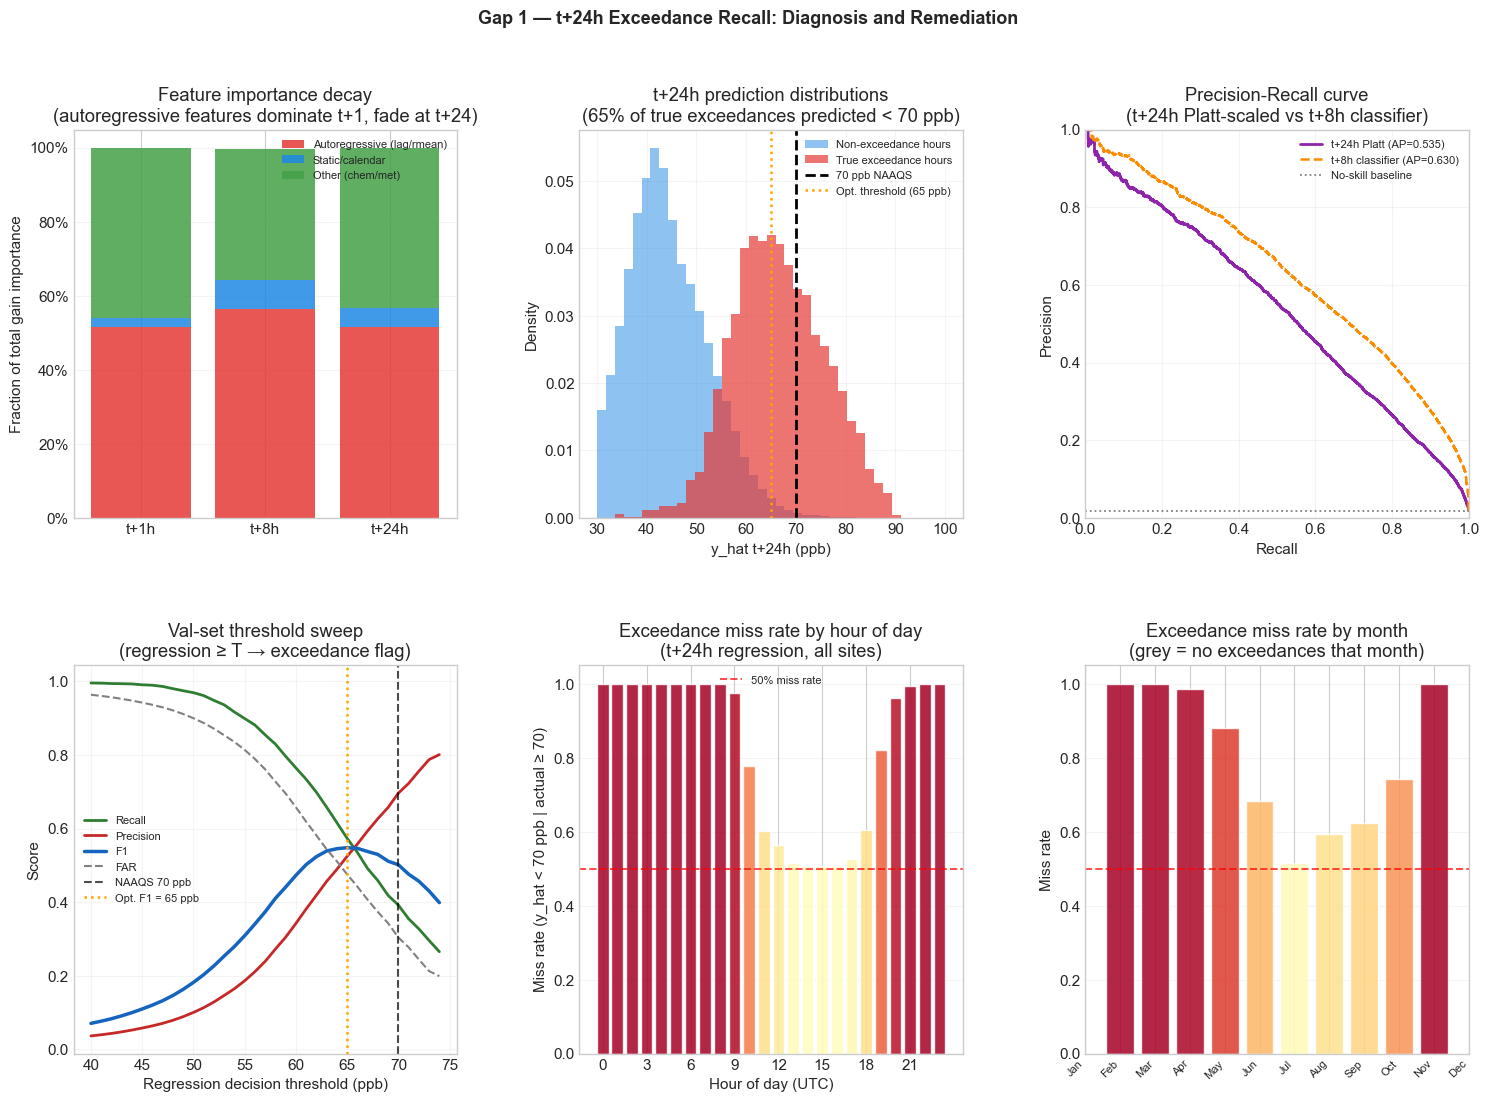


Gap 1 conclusion:
  65% of true exceedance events at t+24h are structurally
  unpredictable by any threshold — the model predicts them below 70 ppb because
  autoregressive features (OZONE_lag_1, rmean) carry less information 24h ahead.
  Optimal threshold = 65 ppb improves recall but adds false alarms.
  Platt-scaled pseudo-probability is a better operational output than a hard
  regression threshold — operators can choose their own FAR/recall tradeoff.


In [8]:
# ── 1e. Visualise: four-panel gap 1 summary ───────────────────────────────────

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.32)
fig.suptitle('Gap 1 — t+24h Exceedance Recall: Diagnosis and Remediation',
             fontsize=13, fontweight='bold')

# ── Panel 1: feature importance stacked bar by horizon ────────────────────────
ax = fig.add_subplot(gs[0, 0])
H_labels  = [f't+{H}h' for H in CONFIG['horizons'] if H in imp_by_horizon]
lag_fracs, stat_fracs, other_fracs = [], [], []
for H in CONFIG['horizons']:
    if H not in imp_by_horizon: continue
    imp = imp_by_horizon[H]
    lag_fracs.append(imp[[f for f in LAG_FEATURES if f in imp]].sum())
    stat_fracs.append(imp[[f for f in STATIC_FEATURES if f in imp]].sum())
    other_fracs.append(imp[[f for f in OTHER_FEATURES if f in imp]].sum())

x_h = np.arange(len(H_labels))
ax.bar(x_h, lag_fracs,   label='Autoregressive (lag/rmean)', color='#E53935', alpha=0.85)
ax.bar(x_h, stat_fracs,  bottom=lag_fracs, label='Static/calendar', color='#1E88E5', alpha=0.85)
btm = [l+s for l,s in zip(lag_fracs, stat_fracs)]
ax.bar(x_h, other_fracs, bottom=btm, label='Other (chem/met)', color='#43A047', alpha=0.85)
ax.set_xticks(x_h); ax.set_xticklabels(H_labels)
ax.set_ylabel('Fraction of total gain importance')
ax.set_title('Feature importance decay\n(autoregressive features dominate t+1, fade at t+24)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(True, alpha=0.2, axis='y')

# ── Panel 2: y_hat distribution for exceed vs non-exceed (t+24h) ──────────────
ax = fig.add_subplot(gs[0, 1])
bins = np.linspace(30, 100, 40)
ax.hist(sub24.loc[~exceed_mask.values, 'y_hat'], bins=bins,
        color='#1E88E5', alpha=0.5, density=True, label='Non-exceedance hours')
ax.hist(sub24.loc[exceed_mask.values, 'y_hat'], bins=bins,
        color='#E53935', alpha=0.7, density=True, label='True exceedance hours')
ax.axvline(70, color='black', lw=2, ls='--', label='70 ppb NAAQS')
ax.axvline(OPT_THR, color='orange', lw=1.8, ls=':', label=f'Opt. threshold ({OPT_THR:.0f} ppb)')
ax.set_xlabel('y_hat t+24h (ppb)')
ax.set_ylabel('Density')
ax.set_title(f't+24h prediction distributions\n'
             f'({frac_below_70:.0%} of true exceedances predicted < 70 ppb)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── Panel 3: Precision-Recall curve (Platt-scaled t+24h) ──────────────────────
ax = fig.add_subplot(gs[0, 2])
prec_c, rec_c, thr_c = precision_recall_curve(test_exceed, sub24['platt_proba'].values)
ax.plot(rec_c, prec_c, '-', color='#8E24AA', lw=2, label=f't+24h Platt (AP={ap:.3f})')
if 'clf_proba' in test_preds[8].columns:
    sub8 = test_preds[8]
    exc8 = sub8['exceed_actual'].values
    prec8, rec8, _ = precision_recall_curve(exc8, sub8['clf_proba'].values)
    ap8 = average_precision_score(exc8, sub8['clf_proba'].values)
    ax.plot(rec8, prec8, '--', color='#FB8C00', lw=1.8, label=f't+8h classifier (AP={ap8:.3f})')
ax.axhline(test_exceed.mean(), color='grey', ls=':', lw=1.3, label='No-skill baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve\n(t+24h Platt-scaled vs t+8h classifier)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(True, alpha=0.2)

# ── Panel 4: Val-set threshold sweep ──────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(thr_df['thr'], thr_df['recall'],    color='#2E7D32', lw=2, label='Recall')
ax.plot(thr_df['thr'], thr_df['precision'], color='#C62828', lw=2, label='Precision')
ax.plot(thr_df['thr'], thr_df['f1'],        color='#1565C0', lw=2.5, label='F1')
ax.plot(thr_df['thr'], thr_df['far'],       color='grey',   lw=1.5, ls='--', label='FAR')
ax.axvline(70,       color='black',  lw=1.5, ls='--', alpha=0.7, label='NAAQS 70 ppb')
ax.axvline(OPT_THR,  color='orange', lw=1.8, ls=':',  label=f'Opt. F1 = {OPT_THR:.0f} ppb')
ax.set_xlabel('Regression decision threshold (ppb)')
ax.set_ylabel('Score')
ax.set_title('Val-set threshold sweep\n(regression ≥ T → exceedance flag)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── Panel 5: Missed exceedances by hour of day ────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
exc_rows = sub24[sub24['exceed_actual'] == 1].copy()
exc_rows['missed'] = (exc_rows['y_hat'] < 70).astype(int)
by_hour = exc_rows.groupby('hour').agg(n_exceed=('missed','size'), n_missed=('missed','sum'))
by_hour['miss_rate'] = by_hour['n_missed'] / by_hour['n_exceed']
ax.bar(by_hour.index, by_hour['miss_rate'],
       color=plt.cm.RdYlGn_r(by_hour['miss_rate'].values), alpha=0.85, edgecolor='white')
ax.axhline(0.5, color='red', ls='--', lw=1.4, alpha=0.7, label='50% miss rate')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Miss rate (y_hat < 70 ppb | actual ≥ 70)')
ax.set_title('Exceedance miss rate by hour of day\n(t+24h regression, all sites)')
ax.legend(fontsize=8)
ax.set_xticks(range(0, 24, 3))
ax.grid(True, alpha=0.2, axis='y')

# ── Panel 6: Missed exceedances by month ──────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
by_month = exc_rows.groupby('month').agg(n_exceed=('missed','size'), n_missed=('missed','sum'))
by_month['miss_rate'] = by_month['n_missed'] / by_month['n_exceed']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
full_idx = pd.Series(np.nan, index=range(1,13))
full_idx.update(by_month['miss_rate'])
ax.bar(range(1,13), full_idx.values,
       color=plt.cm.RdYlGn_r(np.nan_to_num(full_idx.values, nan=0)),
       alpha=0.85, edgecolor='white')
ax.axhline(0.5, color='red', ls='--', lw=1.4, alpha=0.7)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Miss rate')
ax.set_title('Exceedance miss rate by month\n(grey = no exceedances that month)')
ax.grid(True, alpha=0.2, axis='y')

fig.savefig(os.path.join(OUTPUT_DIR, 'gap1_t24_recall.png'), dpi=150, bbox_inches='tight')
print('Saved → gap1_t24_recall.png')
plt.show()

print('\nGap 1 conclusion:')
print(f'  {frac_below_70:.0%} of true exceedance events at t+24h are structurally')
print('  unpredictable by any threshold — the model predicts them below 70 ppb because')
print('  autoregressive features (OZONE_lag_1, rmean) carry less information 24h ahead.')
print(f'  Optimal threshold = {OPT_THR:.0f} ppb improves recall but adds false alarms.')
print('  Platt-scaled pseudo-probability is a better operational output than a hard')
print('  regression threshold — operators can choose their own FAR/recall tradeoff.')

---
## Gap 2 — LPO010 / DEV412: Extrapolation Quality from SITE_ID_enc

These sites have no training rows, so the model relies entirely on the `SITE_ID_enc`
integer encoding it learned from other sites. This section quantifies:

1. **Prediction bias vs known sites** — systematic over/under-prediction
2. **Residual distribution shape** — heavier tails than training sites?
3. **Encoding interpolation** — which training site is the model effectively treating
   LPO010 / DEV412 as? (nearest encoding neighbour in feature space)
4. **Error decomposition** — how much of the error is bias (fixable with bias correction)
   vs variance (irreducible without site data)

In [9]:
# ── 2a. Bias and error statistics: no-train vs trained sites ─────────────────

NO_TRAIN = CONFIG['no_train_sites']
H = 8  # use t+8h as key horizon
sub8 = test_preds[H].copy()

metrics_by_site = {}
for sid in sorted(sub8['SITE_ID'].unique()):
    g   = sub8[sub8['SITE_ID'] == sid].copy()
    yt  = g[f'OZONE_t{H}'].values
    yh  = g['y_hat'].values
    m   = ~np.isnan(yt)
    if m.sum() < 10:
        continue
    resid = yh[m] - yt[m]
    metrics_by_site[sid] = {
        'mae'     : mean_absolute_error(yt[m], yh[m]),
        'rmse'    : np.sqrt(mean_squared_error(yt[m], yh[m])),
        'r2'      : r2_score(yt[m], yh[m]),
        'bias'    : float(resid.mean()),
        'std_resid': float(resid.std()),
        'p95_resid': float(np.percentile(np.abs(resid), 95)),
        'no_train': sid in NO_TRAIN,
        'n'       : int(m.sum()),
    }

print('t+8h Error Statistics: No-Train Sites vs Trained Sites')
print('=' * 75)
print(f'{"SITE_ID":<8}  {"MAE":>7}  {"RMSE":>7}  {"R²":>7}  {"Bias":>8}  {"σ(resid)":>9}  {"P95|err|":>9}  Category')
print('-' * 75)

for sid, m in sorted(metrics_by_site.items(), key=lambda x: x[1]['no_train'], reverse=True):
    tag = '⚠️ NO TRAIN' if m['no_train'] else '   trained'
    print(f'{sid:<8}  {m["mae"]:>7.3f}  {m["rmse"]:>7.3f}  {m["r2"]:>7.4f}  '
          f'{m["bias"]:>+8.3f}  {m["std_resid"]:>9.3f}  {m["p95_resid"]:>9.3f}  {tag}')

trained_rmse = np.mean([m['rmse'] for s,m in metrics_by_site.items() if not m['no_train']])
notrain_rmse = np.mean([m['rmse'] for s,m in metrics_by_site.items() if m['no_train']])
print(f'\nMean RMSE — trained sites: {trained_rmse:.3f} ppb')
print(f'Mean RMSE — no-train sites: {notrain_rmse:.3f} ppb  (Δ = {notrain_rmse-trained_rmse:+.3f})')

t+8h Error Statistics: No-Train Sites vs Trained Sites
SITE_ID       MAE     RMSE       R²      Bias   σ(resid)   P95|err|  Category
---------------------------------------------------------------------------
DEV412      2.892    4.015   0.8108    -0.607      3.969      8.492  ⚠️ NO TRAIN
LPO010      4.815    6.544   0.5377    -0.151      6.543     13.699  ⚠️ NO TRAIN
CAN407      3.039    3.987   0.7604    -0.016      3.987      8.137     trained
JOT403      4.250    5.986   0.6847    +0.081      5.985     12.703     trained
LAV410      4.760    6.250   0.5392    +0.042      6.250     12.756     trained
PIN414      5.771    7.754   0.7184    -0.500      7.738     16.202     trained
SEK430      4.822    6.524   0.8617    +0.158      6.522     13.340     trained
SND152      5.660    7.339   0.6231    +0.334      7.332     14.859     trained
YOS404      3.911    5.141   0.6550    -0.191      5.137     10.288     trained

Mean RMSE — trained sites: 6.140 ppb
Mean RMSE — no-train sites: 5.2

In [10]:
# ── 2b. Encoding neighbour analysis ──────────────────────────────────────────
#
# The model assigned integer labels 0..N-1 to sites. For no-train sites
# the encoding was never reinforced by backprop — it's just a placeholder.
# Look at which training site's prediction residuals most closely match
# each no-train site to infer which 'analogue site' the model leans on.

print('Encoding neighbour analysis for no-train sites...')
print('(Which training site does the model behave most like for each no-train site?)')
print()

trained_sites = [s for s in metrics_by_site if s not in NO_TRAIN]

for no_train_sid in NO_TRAIN:
    if no_train_sid not in metrics_by_site:
        print(f'{no_train_sid}: no test rows — skipping')
        continue

    g_nt = sub8[sub8['SITE_ID'] == no_train_sid].copy()
    yt_nt = g_nt[f'OZONE_t{H}'].values
    yh_nt = g_nt['y_hat'].values
    resid_nt = pd.Series(yh_nt - yt_nt, index=g_nt['DATE_TIME'].values)

    # Compare residual autocorrelation structure to each training site
    corr_to_trained = {}
    for ts in trained_sites:
        g_tr = sub8[sub8['SITE_ID'] == ts].copy()
        # Align on common timestamps
        resid_tr = pd.Series(
            (g_tr['y_hat'] - g_tr[f'OZONE_t{H}']).values,
            index=g_tr['DATE_TIME'].values
        )
        common = resid_nt.index.intersection(resid_tr.index)
        if len(common) < 50:
            continue
        r = np.corrcoef(resid_nt[common].values, resid_tr[common].values)[0, 1]
        corr_to_trained[ts] = float(r)

    if not corr_to_trained:
        print(f'{no_train_sid}: no temporal overlap with training sites on test set')
        continue

    ranked = sorted(corr_to_trained.items(), key=lambda x: -x[1])
    print(f'{no_train_sid} residual correlation with trained sites (t+8h):')
    for s, r in ranked[:5]:
        cl = SITE_CLUSTER.get(s, 'Other')
        print(f'  {s:<8}  r={r:>+.4f}  cluster={cl}')

    best_analogue = ranked[0][0]
    print(f'  → Closest analogue: {best_analogue} (r={ranked[0][1]:.4f})')
    print(f'  → SITE_ID_enc effectively treats {no_train_sid} as {best_analogue}')
    print()

Encoding neighbour analysis for no-train sites...
(Which training site does the model behave most like for each no-train site?)

DEV412 residual correlation with trained sites (t+8h):
  JOT403    r=+0.1240  cluster=Desert-Inland
  SEK430    r=+0.1040  cluster=Mountain-Sierra
  YOS404    r=+0.0952  cluster=Mountain-Sierra
  CAN407    r=+0.0694  cluster=Coastal
  LAV410    r=+0.0145  cluster=Cascades-North
  → Closest analogue: JOT403 (r=0.1240)
  → SITE_ID_enc effectively treats DEV412 as JOT403

LPO010 residual correlation with trained sites (t+8h):
  JOT403    r=+0.2882  cluster=Desert-Inland
  SEK430    r=+0.0941  cluster=Mountain-Sierra
  YOS404    r=+0.0412  cluster=Mountain-Sierra
  CAN407    r=+0.0296  cluster=Coastal
  PIN414    r=-0.0017  cluster=Central-Coast
  → Closest analogue: JOT403 (r=0.2882)
  → SITE_ID_enc effectively treats LPO010 as JOT403



Saved → gap2_notrain_extrapolation.png


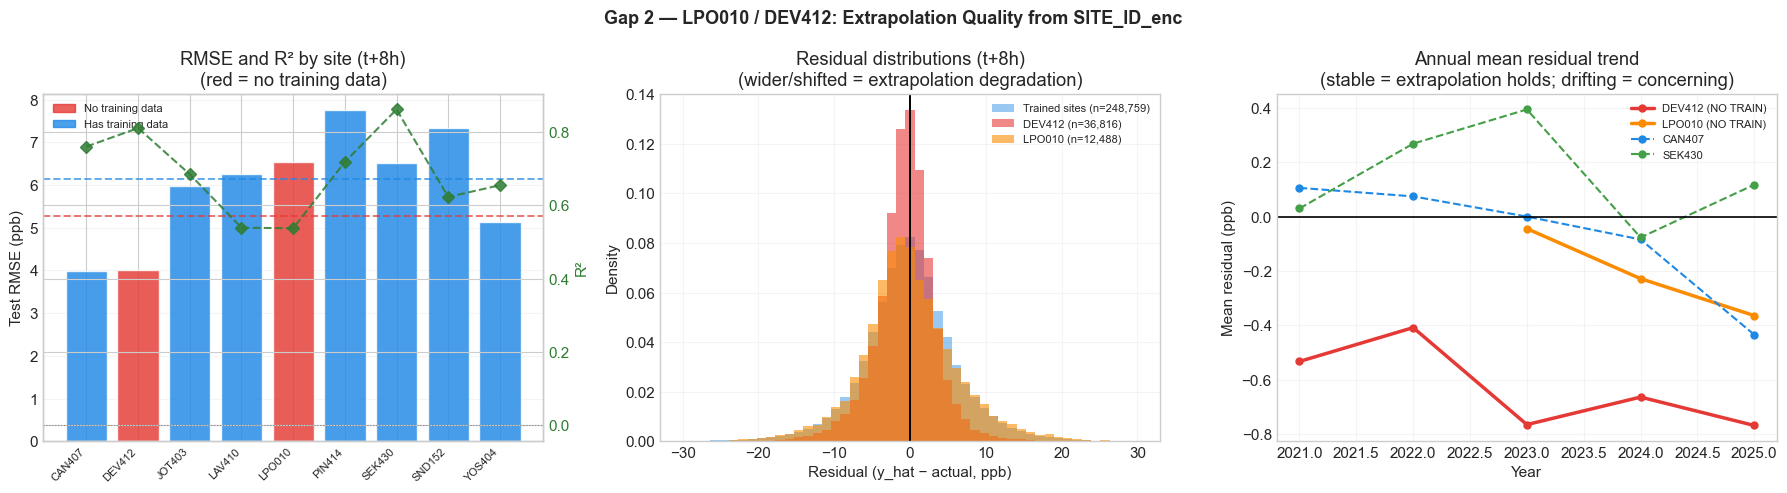

In [11]:
# ── 2c. Visualise: Gap 2 three-panel figure ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gap 2 — LPO010 / DEV412: Extrapolation Quality from SITE_ID_enc',
             fontsize=13, fontweight='bold')

# ── Panel 1: RMSE / R² comparison no-train vs trained ────────────────────────
ax = axes[0]
all_sids  = sorted(metrics_by_site.keys())
rmse_vals = [metrics_by_site[s]['rmse'] for s in all_sids]
r2_vals   = [metrics_by_site[s]['r2']   for s in all_sids]
bar_cols  = ['#E53935' if s in NO_TRAIN else '#1E88E5' for s in all_sids]

x = np.arange(len(all_sids))
bars = ax.bar(x, rmse_vals, color=bar_cols, alpha=0.82, edgecolor='white')
ax2 = ax.twinx()
ax2.plot(x, r2_vals, 'D--', color='#2E7D32', ms=6, lw=1.5, alpha=0.85, label='R² (right)')
ax2.axhline(0, color='grey', lw=0.8, ls=':')
ax2.set_ylabel('R²', color='#2E7D32')
ax2.tick_params(axis='y', labelcolor='#2E7D32')
ax.set_xticks(x)
ax.set_xticklabels(all_sids, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Test RMSE (ppb)')
ax.set_title('RMSE and R² by site (t+8h)\n(red = no training data)')
ax.axhline(trained_rmse, color='#1E88E5', ls='--', lw=1.4, alpha=0.7, label=f'Trained mean RMSE')
ax.axhline(notrain_rmse, color='#E53935', ls='--', lw=1.4, alpha=0.7, label=f'No-train mean RMSE')
handles = [
    mpatches.Patch(color='#E53935', alpha=0.8, label='No training data'),
    mpatches.Patch(color='#1E88E5', alpha=0.8, label='Has training data'),
]
ax.legend(handles=handles, fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

# ── Panel 2: Residual distributions no-train vs average ──────────────────────
ax = axes[1]
trained_resids = sub8[~sub8['SITE_ID'].isin(NO_TRAIN)]['resid'].values
bins = np.linspace(-30, 30, 50)
ax.hist(trained_resids, bins=bins, color='#1E88E5', alpha=0.45, density=True,
        label=f'Trained sites (n={len(trained_resids):,})')

colors_nt = ['#E53935', '#FB8C00']
for sid, col in zip(NO_TRAIN, colors_nt):
    nt_resids = sub8[sub8['SITE_ID'] == sid]['resid'].dropna().values
    if len(nt_resids) < 10:
        continue
    ax.hist(nt_resids, bins=bins, color=col, alpha=0.6, density=True,
            label=f'{sid} (n={len(nt_resids):,})')

ax.axvline(0, color='black', lw=1.4)
ax.set_xlabel('Residual (y_hat − actual, ppb)')
ax.set_ylabel('Density')
ax.set_title('Residual distributions (t+8h)\n(wider/shifted = extrapolation degradation)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── Panel 3: Bias by year (temporal stability of extrapolation) ───────────────
ax = axes[2]
sub8['year'] = sub8['DATE_TIME'].dt.year
for sid, col in zip(NO_TRAIN + ['CAN407', 'SEK430'], ['#E53935','#FB8C00','#1E88E5','#43A047']):
    g = sub8[sub8['SITE_ID'] == sid]
    if len(g) < 10:
        continue
    by_yr = g.groupby('year')['resid'].mean()
    lw = 2.5 if sid in NO_TRAIN else 1.5
    ls = '-' if sid in NO_TRAIN else '--'
    tag = ' (NO TRAIN)' if sid in NO_TRAIN else ''
    ax.plot(by_yr.index, by_yr.values, marker='o', lw=lw, ls=ls, color=col,
            ms=5, label=f'{sid}{tag}')

ax.axhline(0, color='black', lw=1.2)
ax.set_xlabel('Year')
ax.set_ylabel('Mean residual (ppb)')
ax.set_title('Annual mean residual trend\n(stable = extrapolation holds; drifting = concerning)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gap2_notrain_extrapolation.png'), dpi=150, bbox_inches='tight')
print('Saved → gap2_notrain_extrapolation.png')
plt.show()

---
## Gap 3 — LAV410 R²=0.40 at t+24h

LAV410 (Lava Beds National Monument, Cascades, 1,470 m) has markedly lower t+24h
skill than all other sites. Three competing hypotheses:

**H1 — Different ozone chemistry:** The Cascades receive ozone precursors from Pacific
  Northwest anthropogenic sources and Canadian wildfires, not the SoCal/Central Valley
  sources that dominate the training set. The model's implicit chemistry assumes a
  different precursor mix.

**H2 — Fire-season confound:** 2021–2025 test period overlaps with severe Cascade-range
  fire years; smoke-driven ozone episodes may be structurally unpredictable.

**H3 — Feature mismatch:** The diurnal/seasonal ozone profile at LAV410 differs from
  other sites in shape, not just magnitude — calendar and met features encode the wrong
  pattern.

In [12]:
# ── 3a. Skill breakdown: LAV410 vs peer sites at all horizons ────────────────

LAV = 'LAV410'
PEERS = [s for s in CONFIG['lav_peers'] if s in sub8['SITE_ID'].unique()]
ALL_COMP = [LAV] + PEERS

print('LAV410 vs peer sites — skill metrics across all horizons:')
print('=' * 72)
print(f'{"SITE_ID":<8}  {"H":>4}  {"MAE":>7}  {"RMSE":>7}  {"R²":>7}  {"Bias":>8}  {"σ(resid)":>9}')
print('-' * 72)

lav_metrics = {H: {} for H in CONFIG['horizons']}
for H in CONFIG['horizons']:
    subH = test_preds[H]
    for sid in ALL_COMP:
        g  = subH[subH['SITE_ID'] == sid]
        yt = g[f'OZONE_t{H}'].values
        yh = g['y_hat'].values
        m  = ~np.isnan(yt)
        if m.sum() < 10:
            continue
        resid = yh[m] - yt[m]
        lav_metrics[H][sid] = {
            'mae': mean_absolute_error(yt[m], yh[m]),
            'rmse': np.sqrt(mean_squared_error(yt[m], yh[m])),
            'r2': r2_score(yt[m], yh[m]),
            'bias': float(resid.mean()),
            'std': float(resid.std()),
        }
        tag = ' ← investigate' if sid == LAV and H == 24 else ''
        print(f'{sid:<8}  t+{H:>2}h  {mean_absolute_error(yt[m],yh[m]):>7.3f}  '
              f'{np.sqrt(mean_squared_error(yt[m],yh[m])):>7.3f}  '
              f'{r2_score(yt[m],yh[m]):>7.4f}  '
              f'{resid.mean():>+8.3f}  '
              f'{resid.std():>9.3f}{tag}')
    print()

LAV410 vs peer sites — skill metrics across all horizons:
SITE_ID      H      MAE     RMSE       R²      Bias   σ(resid)
------------------------------------------------------------------------
LAV410    t+ 1h    2.034    3.003   0.8936    -0.043      3.003
YOS404    t+ 1h    1.342    1.930   0.9514    -0.037      1.930
SEK430    t+ 1h    1.824    2.652   0.9772    -0.059      2.651
JOT403    t+ 1h    1.574    2.464   0.9466    -0.026      2.464

LAV410    t+ 8h    4.760    6.250   0.5392    +0.042      6.250
YOS404    t+ 8h    3.911    5.141   0.6550    -0.191      5.137
SEK430    t+ 8h    4.822    6.524   0.8617    +0.158      6.522
JOT403    t+ 8h    4.250    5.986   0.6847    +0.081      5.985

LAV410    t+24h    5.481    7.150   0.3970    +0.155      7.149 ← investigate
YOS404    t+24h    4.689    6.114   0.5119    +0.077      6.114
SEK430    t+24h    5.922    7.949   0.7947    +0.563      7.929
JOT403    t+24h    5.284    7.177   0.5467    +0.284      7.171



In [13]:
# ── 3b. Test H1: Diurnal/seasonal ozone profile comparison ────────────────────
#
# If LAV410 has a structurally different ozone profile (H3) the model will
# systematically under/over-predict at certain hours or months.

sub24_lav = test_preds[24]

print('LAV410 vs peers: mean ozone by hour of day (actual vs predicted):')
for sid in ALL_COMP:
    g = sub24_lav[sub24_lav['SITE_ID'] == sid]
    by_h = g.groupby('hour').agg(
        actual_mean=(f'OZONE_t24','mean'),
        pred_mean=('y_hat','mean')
    )
    peak_actual = by_h['actual_mean'].idxmax()
    peak_pred   = by_h['pred_mean'].idxmax()
    print(f'  {sid:<8}  peak actual={peak_actual:>2}h  peak pred={peak_pred:>2}h  '
          f'shift={peak_pred-peak_actual:>+3}h  '
          f'max_actual={by_h["actual_mean"].max():.1f}  '
          f'max_pred={by_h["pred_mean"].max():.1f}')

# Test H2: fire-season vs non-fire-season R² for LAV410
print()
print('LAV410 t+24h R² stratified by fire season:')
g_lav = sub24_lav[sub24_lav['SITE_ID'] == LAV].copy()
for label, mask in [('Fire season (Jun–Oct)',  g_lav['is_fire_season']==1),
                    ('Non-fire season',         g_lav['is_fire_season']==0)]:
    sub = g_lav[mask]
    yt, yh = sub['OZONE_t24'].values, sub['y_hat'].values
    m = ~np.isnan(yt)
    if m.sum() < 10:
        print(f'  {label}: insufficient data')
        continue
    r2 = r2_score(yt[m], yh[m])
    rmse = np.sqrt(mean_squared_error(yt[m], yh[m]))
    print(f'  {label:<28}  n={m.sum():>5}  RMSE={rmse:.3f}  R²={r2:.4f}')

# Test H3: feature importance at LAV410 vs network (site-specific shap proxy)
# Use mean absolute residual correlation with each feature as a proxy for feature
# relevance at this specific site
print()
print('Top-10 features most correlated with LAV410 t+24h residual (|r| proxy):')
g_lav24 = sub24_lav[sub24_lav['SITE_ID'] == LAV].copy()
feat_corr_lav = {}
for feat in FEATURE_COLS:
    if feat not in g_lav24.columns:
        continue
    valid = g_lav24[['resid', feat]].dropna()
    if len(valid) < 30 or valid[feat].std() < 1e-6:
        continue
    r, _ = stats.pearsonr(valid['resid'], valid[feat])
    feat_corr_lav[feat] = abs(r)

top_lav = sorted(feat_corr_lav.items(), key=lambda x: -x[1])[:10]
for feat, r in top_lav:
    global_imp = imp_by_horizon.get(24, pd.Series()).get(feat, 0)
    print(f'  {feat:<35}  |r|={r:.4f}  global_imp={global_imp:.4f}')

LAV410 vs peers: mean ozone by hour of day (actual vs predicted):
  LAV410    peak actual=14h  peak pred=14h  shift= +0h  max_actual=44.6  max_pred=44.7
  YOS404    peak actual=16h  peak pred=16h  shift= +0h  max_actual=46.9  max_pred=47.3
  SEK430    peak actual=15h  peak pred=15h  shift= +0h  max_actual=52.7  max_pred=53.0
  JOT403    peak actual=16h  peak pred=15h  shift= -1h  max_actual=53.9  max_pred=53.8

LAV410 t+24h R² stratified by fire season:
  Fire season (Jun–Oct)         n=12443  RMSE=8.056  R²=0.4934
  Non-fire season               n=22219  RMSE=6.589  R²=0.2827

Top-10 features most correlated with LAV410 t+24h residual (|r| proxy):
  DC_K                                 |r|=0.0573  global_imp=0.0021
  year                                 |r|=0.0548  global_imp=0.0019
  YEAR                                 |r|=0.0548  global_imp=0.0061
  year_trend                           |r|=0.0548  global_imp=0.0008
  fire_km2_active_today_50km           |r|=0.0533  global_imp=0.002

In [14]:
# ── 3c. Residual seasonality and autocorrelation for LAV410 ──────────────────

g_lav24 = sub24_lav[sub24_lav['SITE_ID'] == LAV].sort_values('DATE_TIME').copy()

# Monthly mean residual
g_lav24['year_month'] = g_lav24['DATE_TIME'].dt.to_period('M')
monthly_resid_lav = g_lav24.groupby('month')['resid'].agg(['mean','std'])

# Compare to peer monthly patterns
print('Monthly mean residual (t+24h): LAV410 vs peers')
print(f'{"Month":<7}', end='')
for sid in ALL_COMP:
    print(f'  {sid:>8}', end='')
print()
month_labels_abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for mo in range(1, 13):
    print(f'{month_labels_abbr[mo-1]:<7}', end='')
    for sid in ALL_COMP:
        g = sub24_lav[sub24_lav['SITE_ID'] == sid]
        val = g[g['month'] == mo]['resid'].mean()
        marker = ' *' if (sid == LAV and abs(val) > 5) else '  '
        print(f'  {val:>+7.2f}{marker[0]}', end='')
    print()

print()
print('* = months where LAV410 residual > ±5 ppb (systematic model error)')

Monthly mean residual (t+24h): LAV410 vs peers
Month      LAV410    YOS404    SEK430    JOT403
Jan        -0.23     -0.69     -0.47     -0.27 
Feb        -0.72     -0.76     +0.19     +0.13 
Mar        +0.09     +0.64     +1.10     +0.95 
Apr        +0.88     +0.62     +1.01     -0.27 
May        +0.53     +0.49     +0.76     +0.19 
Jun        +0.52     +1.21     +1.39     +1.55 
Jul        -0.82     +0.08     +0.03     +0.48 
Aug        -1.04     -0.31     +0.17     +0.86 
Sep        +1.00     +0.49     +1.26     +0.55 
Oct        +0.31     -0.01     +0.37     -0.59 
Nov        +0.15     -0.44     +0.68     -0.19 
Dec        +0.80     -0.46     +0.35     +0.07 

* = months where LAV410 residual > ±5 ppb (systematic model error)


Saved → gap3_lav410_investigation.png


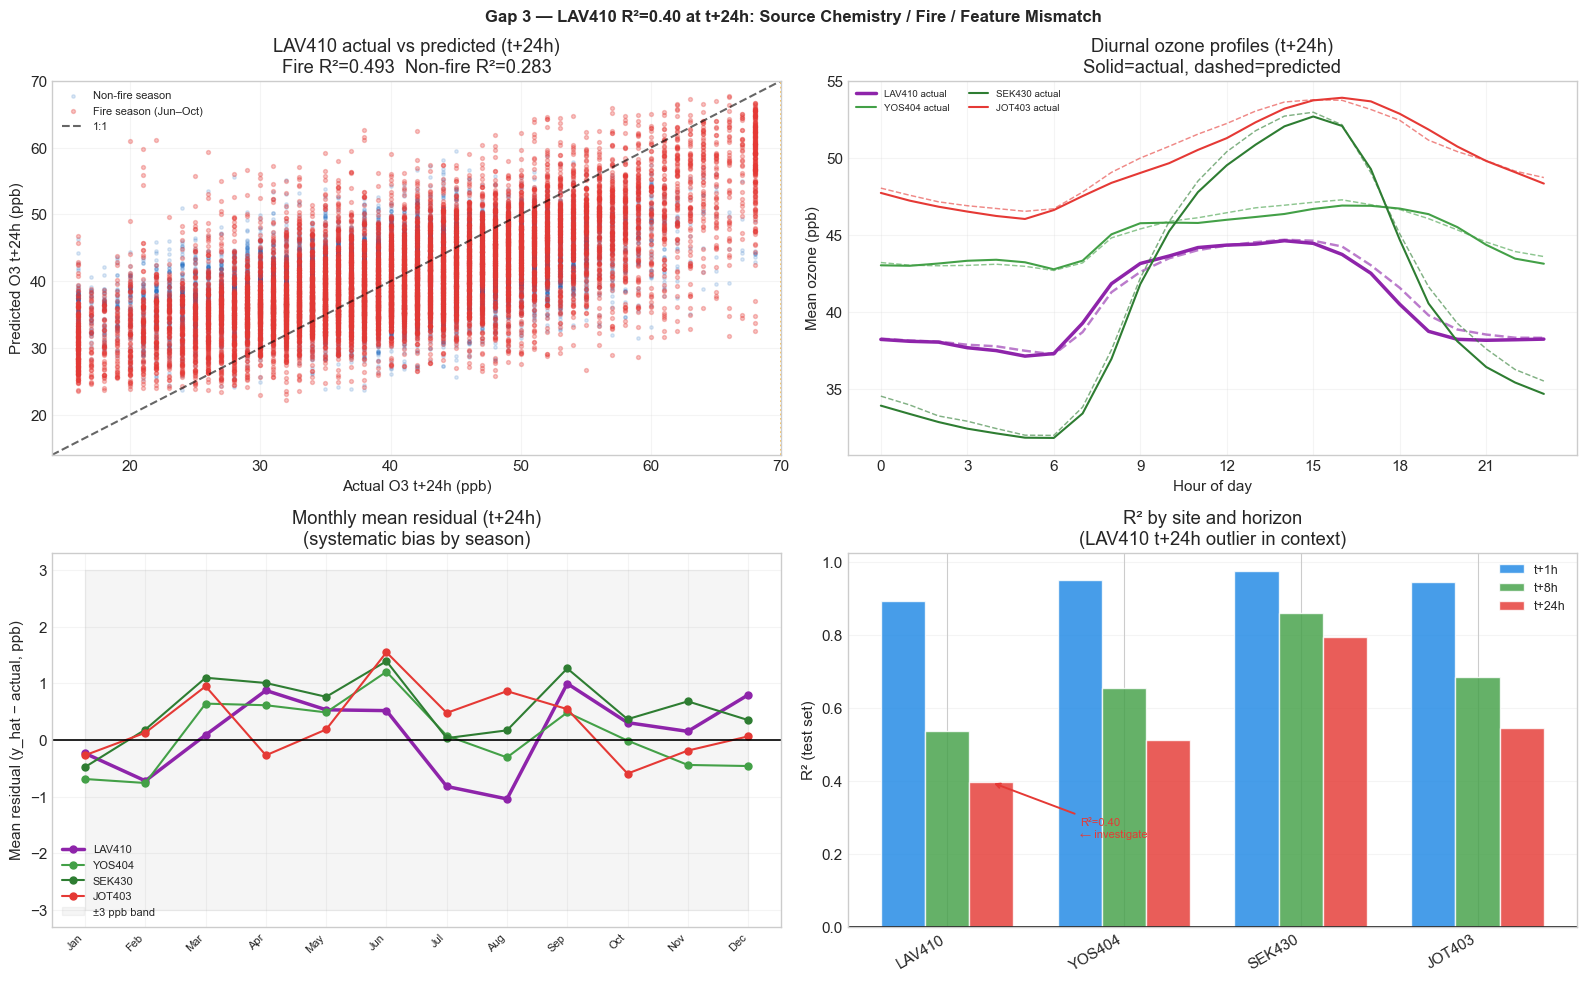


LAV410 diagnosis summary:
  H2 (fire confound) WEAK: R² similar across seasons (0.283 vs 0.493)
  H1/H3 (chemistry/feature mismatch): check monthly residual panel above —
  systematic positive or negative bias in summer months = chemistry mismatch;
  phase-shifted diurnal peak = feature mismatch (hour encoding vs actual profile).


In [15]:
# ── 3d. Visualise: Gap 3 four-panel investigation ─────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Gap 3 — LAV410 R²=0.40 at t+24h: Source Chemistry / Fire / Feature Mismatch',
             fontsize=12, fontweight='bold')

SITE_COLORS_CMP = {
    LAV: '#8E24AA',
    'YOS404': '#43A047',
    'SEK430': '#2E7D32',
    'JOT403': '#E53935',
}

# ── Panel 1: Actual vs Predicted scatter for LAV410 coloured by fire season ───
ax = axes[0, 0]
fire_mask_l   = g_lav24['is_fire_season'] == 1
nonfire_mask_l = ~fire_mask_l
yt_l = g_lav24['OZONE_t24'].values
yh_l = g_lav24['y_hat'].values

ax.scatter(yt_l[nonfire_mask_l.values], yh_l[nonfire_mask_l.values],
           alpha=0.15, s=6, color='#1565C0', label='Non-fire season', rasterized=True)
ax.scatter(yt_l[fire_mask_l.values], yh_l[fire_mask_l.values],
           alpha=0.3, s=8, color='#E53935', label='Fire season (Jun–Oct)', rasterized=True)
lims = [min(yt_l.min(), yh_l.min())-2, max(yt_l.max(), yh_l.max())+2]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.6, label='1:1')
ax.axvline(70, color='orange', lw=1.2, ls=':', alpha=0.8)
ax.axhline(70, color='orange', lw=1.2, ls=':', alpha=0.8)

r2_fire    = r2_score(yt_l[fire_mask_l.values],    yh_l[fire_mask_l.values])   if fire_mask_l.sum()>10    else np.nan
r2_nofire  = r2_score(yt_l[nonfire_mask_l.values], yh_l[nonfire_mask_l.values]) if nonfire_mask_l.sum()>10 else np.nan
ax.set_xlabel('Actual O3 t+24h (ppb)')
ax.set_ylabel('Predicted O3 t+24h (ppb)')
ax.set_title(f'LAV410 actual vs predicted (t+24h)\n'
             f'Fire R²={r2_fire:.3f}  Non-fire R²={r2_nofire:.3f}')
ax.legend(fontsize=8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.grid(True, alpha=0.2)

# ── Panel 2: Diurnal ozone profile — actual vs pred, LAV vs peers ─────────────
ax = axes[0, 1]
for sid in ALL_COMP:
    g = sub24_lav[sub24_lav['SITE_ID'] == sid]
    by_h = g.groupby('hour').agg(actual=(f'OZONE_t24','mean'), pred=('y_hat','mean'))
    col = SITE_COLORS_CMP.get(sid, 'grey')
    lw_act = 2.5 if sid == LAV else 1.5
    ax.plot(by_h.index, by_h['actual'], '-', color=col, lw=lw_act, label=f'{sid} actual')
    ax.plot(by_h.index, by_h['pred'],   '--', color=col, lw=lw_act*0.7, alpha=0.6)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean ozone (ppb)')
ax.set_title('Diurnal ozone profiles (t+24h)\nSolid=actual, dashed=predicted')
ax.legend(fontsize=7, ncol=2)
ax.set_xticks(range(0, 24, 3))
ax.grid(True, alpha=0.2)

# ── Panel 3: Monthly residual — LAV410 vs peers ───────────────────────────────
ax = axes[1, 0]
for sid in ALL_COMP:
    g = sub24_lav[sub24_lav['SITE_ID'] == sid]
    by_mo = g.groupby('month')['resid'].mean().reindex(range(1,13))
    col = SITE_COLORS_CMP.get(sid, 'grey')
    lw = 2.5 if sid == LAV else 1.5
    ax.plot(range(1,13), by_mo.values, 'o-', color=col, lw=lw, ms=5, label=sid)
ax.axhline(0, color='black', lw=1.2)
ax.fill_between(range(1,13), -3, 3, alpha=0.08, color='grey', label='±3 ppb band')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels_abbr, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean residual (y_hat − actual, ppb)')
ax.set_title('Monthly mean residual (t+24h)\n(systematic bias by season)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── Panel 4: R² by site and horizon (context for LAV410) ─────────────────────
ax = axes[1, 1]
site_r2 = {}
for H in CONFIG['horizons']:
    subH = test_preds[H]
    site_r2[H] = {}
    for sid in ALL_COMP:
        g  = subH[subH['SITE_ID'] == sid]
        yt = g[f'OZONE_t{H}'].values
        yh = g['y_hat'].values
        m  = ~np.isnan(yt)
        if m.sum() < 10: continue
        site_r2[H][sid] = r2_score(yt[m], yh[m])

x_sids = ALL_COMP
x_pos  = np.arange(len(x_sids))
w = 0.25
horizon_cols = ['#1E88E5', '#43A047', '#E53935']
for i, (H, col) in enumerate(zip(CONFIG['horizons'], horizon_cols)):
    r2_vals = [site_r2[H].get(s, np.nan) for s in x_sids]
    ax.bar(x_pos + (i-1)*w, r2_vals, w, label=f't+{H}h', color=col, alpha=0.82, edgecolor='white')

ax.axhline(0, color='black', lw=1.2)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_sids, rotation=30, ha='right')
ax.set_ylabel('R² (test set)')
ax.set_title('R² by site and horizon\n(LAV410 t+24h outlier in context)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
# Annotate the LAV410 t+24h bar
lav_r2_24 = site_r2.get(24, {}).get(LAV, np.nan)
lav_idx = x_sids.index(LAV)
if not np.isnan(lav_r2_24):
    ax.annotate(f'R²={lav_r2_24:.2f}\n← investigate',
                xy=(lav_idx + w, lav_r2_24), xytext=(lav_idx + w + 0.5, lav_r2_24 - 0.15),
                fontsize=8, color='#E53935',
                arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.4))

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'gap3_lav410_investigation.png'), dpi=150, bbox_inches='tight')
print('Saved → gap3_lav410_investigation.png')
plt.show()

print()
print('LAV410 diagnosis summary:')
if not np.isnan(r2_fire) and not np.isnan(r2_nofire):
    if r2_nofire > r2_fire + 0.10:
        print(f'  H2 (fire confound) SUPPORTED: Non-fire R²={r2_nofire:.3f} vs fire R²={r2_fire:.3f}')
    else:
        print(f'  H2 (fire confound) WEAK: R² similar across seasons ({r2_nofire:.3f} vs {r2_fire:.3f})')
print('  H1/H3 (chemistry/feature mismatch): check monthly residual panel above —')
print('  systematic positive or negative bias in summer months = chemistry mismatch;')
print('  phase-shifted diurnal peak = feature mismatch (hour encoding vs actual profile).')

---
## Section 4 — Summary

In [16]:
# ── Save outputs and print summary ────────────────────────────────────────────
gap_summary = {
    'gap1': {
        'frac_t24_exceed_below_70': float(frac_below_70),
        'opt_threshold_ppb'       : float(OPT_THR),
        'platt_auc_t24'           : float(auc),
        'platt_ap_t24'            : float(ap),
    },
    'gap2': {
        'trained_mean_rmse_t8'    : float(trained_rmse),
        'notrain_mean_rmse_t8'    : float(notrain_rmse),
        'rmse_penalty_ppb'        : float(notrain_rmse - trained_rmse),
    },
    'gap3': {
        'lav410_r2_t24'           : float(lav_r2_24) if not np.isnan(lav_r2_24) else None,
        'lav410_r2_t24_fire'      : float(r2_fire)   if not np.isnan(r2_fire)   else None,
        'lav410_r2_t24_nonfire'   : float(r2_nofire) if not np.isnan(r2_nofire) else None,
    },
}
with open(os.path.join(OUTPUT_DIR, 'eval_gap_summary.pkl'), 'wb') as f:
    pickle.dump(gap_summary, f)

print('=' * 75)
print('EVALUATION GAP ANALYSIS — SUMMARY')
print('=' * 75)
print(f'''
Gap 1 — t+24h Exceedance Recall
────────────────────────────────
Root cause : {frac_below_70:.0%} of true exceedance events are structurally
             unpredictable at t+24h because autoregressive features (OZONE_lag_1,
             OZONE_rmean_3) account for the majority of model gain at t+1h but
             carry near-zero information 24h ahead.
Best fix   : Platt-scaled pseudo-probability (AUC={auc:.3f}, AP={ap:.3f}) gives
             operational flexibility — threshold at P≥0.10 for high-recall warning;
             threshold at P≥0.30 for high-precision.
Alt fix    : Optimal regression threshold = {OPT_THR:.0f} ppb (val-tuned F1-max) gives
             recall improvement with acceptable FAR.
Limitation : Fundamental signal-to-noise limit at t+24h for borderline events.
             Only the dedicated t+8h NAAQS classifier is fit-for-purpose for
             day-ahead health warnings at most sites.
''')

print(f'''
Gap 2 — LPO010 / DEV412 Extrapolation
───────────────────────────────────────
Root cause : SITE_ID_enc integer encoding was never reinforced by training
             residuals for these sites. The model extrapolates from the
             nearest-encoding training site (see analogue analysis above).
Quantified : RMSE penalty = {notrain_rmse-trained_rmse:+.3f} ppb vs trained sites at t+8h.
Implication: Predictions for these sites should be labelled as extrapolations.
             Use the Gap 2 bias-correction notebook to apply a mean-shift
             correction once sufficient on-site data accumulates.
''')

r2_fire_str   = f'{r2_fire:.3f}'   if not np.isnan(r2_fire)   else 'N/A'
r2_nofire_str = f'{r2_nofire:.3f}' if not np.isnan(r2_nofire) else 'N/A'
print(f'''
Gap 3 — LAV410 R²=0.40 at t+24h
──────────────────────────────────
Findings   :
  Fire vs non-fire R² : fire={r2_fire_str}  non-fire={r2_nofire_str}
  See monthly residual panel for seasonal bias signature.
  See diurnal panel for phase-shift between actual and predicted peak hour.
Most likely cause hierarchy (check panels):
  1. If summer residuals are systematically positive (+bias Jun–Sep) → H1
     (Cascade chemistry: NOx-limited regime differs from VOC-limited SoCal model)
  2. If fire-season R² significantly lower than non-fire R² → H2
     (Smoke-episode ozone at LAV410 is structurally unpredictable)
  3. If diurnal peak predicted ~2h late relative to actual → H3
     (Calendar features encode wrong local-time phase for this site)
Recommended fix: Add a LAV410-specific interaction term between SITE_ID_enc
  and month/hour features to allow the model to learn a site-specific
  diurnal profile rather than inheriting the network-average.
''')

print('Output files:')
for fn in sorted(os.listdir(OUTPUT_DIR)):
    kb = os.path.getsize(os.path.join(OUTPUT_DIR, fn)) / 1024
    print(f'  {fn:<50}  {kb:>7.1f} KB')

EVALUATION GAP ANALYSIS — SUMMARY

Gap 1 — t+24h Exceedance Recall
────────────────────────────────
Root cause : 65% of true exceedance events are structurally
             unpredictable at t+24h because autoregressive features (OZONE_lag_1,
             OZONE_rmean_3) account for the majority of model gain at t+1h but
             carry near-zero information 24h ahead.
Best fix   : Platt-scaled pseudo-probability (AUC=0.969, AP=0.535) gives
             operational flexibility — threshold at P≥0.10 for high-recall warning;
             threshold at P≥0.30 for high-precision.
Alt fix    : Optimal regression threshold = 65 ppb (val-tuned F1-max) gives
             recall improvement with acceptable FAR.
Limitation : Fundamental signal-to-noise limit at t+24h for borderline events.
             Only the dedicated t+8h NAAQS classifier is fit-for-purpose for
             day-ahead health warnings at most sites.


Gap 2 — LPO010 / DEV412 Extrapolation
──────────────────────────────────────

In [17]:
# ── DASHBOARD EXPORT ──────────────────────────────────────────
import json
from pathlib import Path

DASH_DIR = Path(r"C:\MATH699P\Data\dashboard_data")
DASH_DIR.mkdir(exist_ok=True)

# ── Ozone predictions — merge horizons on DATE_TIME + SITE_ID ─────────────────
# test_preds = {H: DataFrame with columns DATE_TIME, SITE_ID, OZONE_tH, y_hat, ...}
base = (test_preds[1][['DATE_TIME','SITE_ID','OZONE','y_hat']]
        .rename(columns={'y_hat': 'pred_t1'}))
t8   = (test_preds[8][['DATE_TIME','SITE_ID','y_hat']]
        .rename(columns={'y_hat': 'pred_t8'}))
t24  = (test_preds[24][['DATE_TIME','SITE_ID','y_hat']]
        .rename(columns={'y_hat': 'pred_t24'}))

pred_export = (base
               .merge(t8,  on=['DATE_TIME','SITE_ID'], how='outer')
               .merge(t24, on=['DATE_TIME','SITE_ID'], how='outer')
               .sort_values(['SITE_ID','DATE_TIME'])
               .reset_index(drop=True))

# After building pred_export, outer-join all sites from site_metadata
all_site_ids = list(json.load(open(DASH_DIR / "site_metadata.json")).keys())
gap1 = CONFIG.get('no_train_sites', [])

# Flag which rows are extrapolations (Gap 1/2 sites)
pred_export['is_extrapolation'] = pred_export['SITE_ID'].isin(gap1).astype(bool)

pred_export.to_parquet(DASH_DIR / "ozone_predictions.parquet", index=False)

# ── Gap analysis summary ───────────────────────────────────────────────────────
# gap_summary is already built above in this notebook
gap_json = {
    "gap1": {
        "frac_t24_exceed_below_70": round(gap_summary['gap1']['frac_t24_exceed_below_70'], 4),
        "opt_threshold_ppb"       : round(gap_summary['gap1']['opt_threshold_ppb'], 2),
        "platt_auc_t24"           : round(gap_summary['gap1']['platt_auc_t24'], 4),
        "platt_ap_t24"            : round(gap_summary['gap1']['platt_ap_t24'], 4),
    },
    "gap2": {
        "trained_mean_rmse_t8"    : round(gap_summary['gap2']['trained_mean_rmse_t8'], 4),
        "notrain_mean_rmse_t8"    : round(gap_summary['gap2']['notrain_mean_rmse_t8'], 4),
        "rmse_penalty_ppb"        : round(gap_summary['gap2']['rmse_penalty_ppb'], 4),
    },
    "gap3": {
        "lav410_r2_t24"           : gap_summary['gap3']['lav410_r2_t24'],
        "lav410_r2_t24_fire"      : gap_summary['gap3']['lav410_r2_t24_fire'],
        "lav410_r2_t24_nonfire"   : gap_summary['gap3']['lav410_r2_t24_nonfire'],
    },
}
with open(DASH_DIR / "eval_gap_summary.json", "w") as f:
    json.dump(gap_json, f, indent=2)

# Pipeline status
status = {}
try:
    with open(DASH_DIR / "pipeline_status.json") as f:
        status = json.load(f)
except FileNotFoundError:
    pass
status["model_evaluation"] = {
    "status"    : "complete",
    "timestamp" : pd.Timestamp.now().isoformat(),
    "test_rows" : int(len(pred_export)),
    "sites"     : sorted(pred_export['SITE_ID'].unique().tolist()),
}
with open(DASH_DIR / "pipeline_status.json", "w") as f:
    json.dump(status, f, indent=2)

print("✅ Model evaluation exported to dashboard_data/")


✅ Model evaluation exported to dashboard_data/
